In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.head())
print(df.shape)
print(df.isnull().sum())
# fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# remove Cabin column
df.drop("Cabin", axis=1, inplace=True)

# remove 2 rows with missing Embarked
df.dropna(subset=["Embarked"], inplace=True)

# check — should show all zeros now!
print(df.isnull().sum())
print(df["Survived"].value_counts())
print(df["Survived"].mean() * 100)
print(df.groupby("Sex")["Survived"].mean() * 100)
print(df.groupby("Pclass")["Survived"].mean() * 100)
print(df.groupby("Survived")["Age"].mean())
children = df[df["Age"] < 10]
print(f"Total children: {len(children)}")
print(f"Children survival rate: {children['Survived'].mean()*100:.1f}%")

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(df.isnull().sum())
df.drop("Cabin", axis=1, inplace=True)
df.dropna(subset=["Embarked"],inplace=True)
df["Age"] = df["Age"].fillna(df["Age"].median())
print(df["Survived"].mean() * 100)
print(df.groupby("Sex")["Survived"].mean()*100)
print(df.groupby("Pclass")["Survived"].mean()*100)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
38.24521934758155
Sex
female    74.038462
male      18.890815
Name: Survived, dtype: float64
Pclass
1    62.616822
2    47.282609
3    24.236253
Name: Survived, dtype: float64


🚢 Titanic Dataset Analysis
Total Passengers: 889
Overall Survival Rate: 38.2%

Survival Rate by Gender:
Sex
female    74.0
male      18.9
Name: Survived, dtype: float64

Survival Rate by Class:
Pclass
1    62.6
2    47.3
3    24.2
Name: Survived, dtype: float64


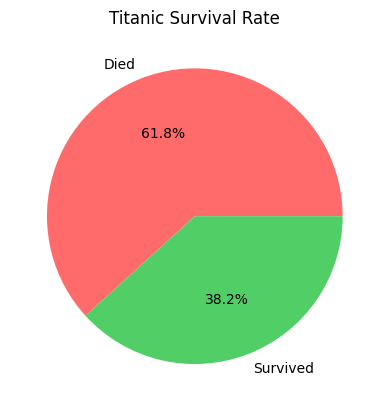

In [ ]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df["Age"] = df["Age"].fillna(df["Age"].median())
df.drop("Cabin", axis=1, inplace=True)
df.dropna(subset=["Embarked"], inplace=True)

print("🚢 Titanic Dataset Analysis")
print("="*40)
print(f"Total Passengers: {len(df)}")
print(f"Overall Survival Rate: {df['Survived'].mean()*100:.1f}%")
print("\nSurvival Rate by Gender:")
print((df.groupby("Sex")["Survived"].mean()*100).round(1))
print("\nSurvival Rate by Class:")
print((df.groupby("Pclass")["Survived"].mean()*100).round(1))
# pie chart — survival on Titanic!
labels  = ["Died", "Survived"]
sizes   = [549, 340]
colors  = ["#ff6b6b", "#51cf66"]

plt.pie(sizes, labels=labels, colors=colors,
        autopct="%1.1f%%")
plt.title("Titanic Survival Rate")
plt.show()


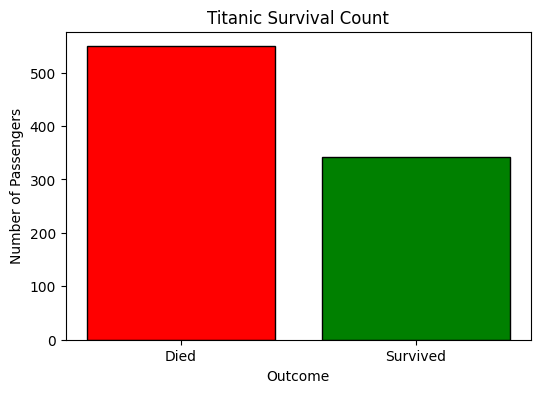

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Died", "Survived"], survival_counts.values,
        color=["red", "green"], edgecolor="black")


plt.title("Titanic Survival Count")
plt.xlabel("Outcome")
plt.ylabel("Number of Passengers")
plt.show()

labels = ['Survived','Died']
size = [549, 340]
plt.pie(size,label=labels,autopct="%1.1f%%")
plt.title("Titanic Survival Rate")
plt.show()

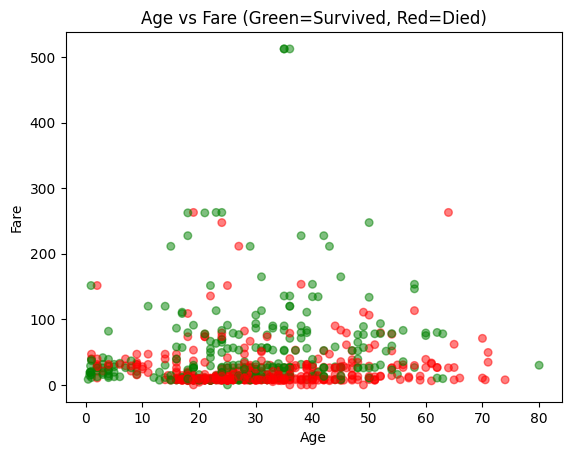

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# remove rows where Age or Fare is missing
df = df.dropna(subset=["Age", "Fare"])

colors = ["green" if s == 1 else "red" for s in df["Survived"]]

plt.scatter(df["Age"], df["Fare"], c=colors, alpha=0.5, s=30)
plt.title("Age vs Fare (Green=Survived, Red=Died)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

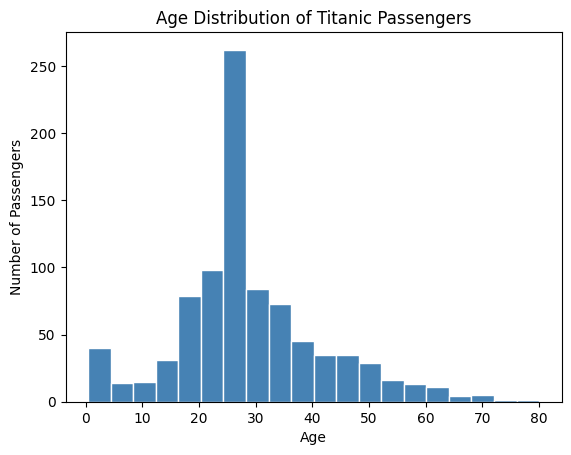

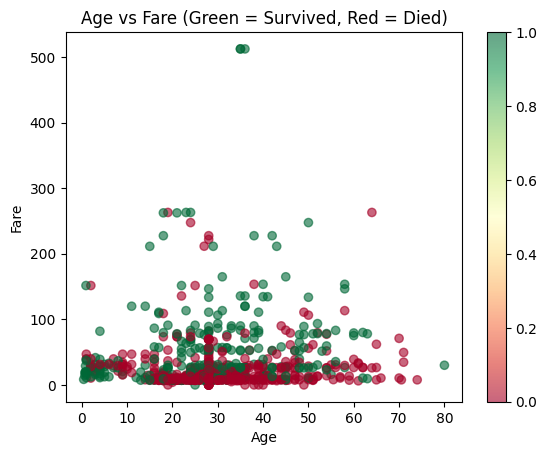

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df["Age"] = df["Age"].fillna(df["Age"].median())

# histogram of ages
plt.hist(df["Age"], bins=20, color="steelblue", edgecolor="white")
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()
# scatter plot — Fare vs Age
plt.scatter(df["Age"], df["Fare"],
            c=df["Survived"],
            cmap="RdYlGn",
            alpha=0.6)

plt.title("Age vs Fare (Green = Survived, Red = Died)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.colorbar()
plt.show()